# Experiments results for transfer learning

Here you will find plots and statistics related to experiments conducted for my thesis. The 2 deep learning model architectures examined are transformer and LSTM. The models were trained with these parameters:
- Transformer: 30 epochs with early stopping
- LSTM: 5 epochs with early stopping
- CNN: 30 epochs with early stopping

## Loading the required python packages for processing

Loading global constant variables as well as useful functions

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import pyperclip
import os

DATASET_NAMES = ("iotid20", "ustc-tfc-2016", "IoT-DS2", "CIC-UNSW-NB15", "mqtt-iot-ids2020", "ids-2018", "IoT-23")
DATASET_MAP = dict(zip(range(1, len(DATASET_NAMES) + 1), DATASET_NAMES))
RESULTS_DIR = "../../results/reports"

def get_models_performance(transformer_csv, lstm_csv, metric="Accuracy"):
    transformer_df = pd.read_csv(transformer_csv)
    lstm_df = pd.read_csv(lstm_csv)
    normal_accuracy_per_dataset = pd.DataFrame()
    attack_accuracy_per_dataset = pd.DataFrame()
    for i, dataset_name in DATASET_MAP.items():
        trans_normals_accuracy = transformer_df.loc[(transformer_df["Class"] == 'Normal') & (transformer_df["Fold #"] == i)][metric].mean()
        trans_attack_accuracy = transformer_df.loc[(transformer_df["Class"] == 'Attack') & (transformer_df["Fold #"] == i)][metric].mean()
        lstm_normals_accuracy = lstm_df.loc[(lstm_df["Class"] == 'Normal') & (lstm_df["Fold #"] == i)][metric].mean()
        lstm_attack_accuracy = lstm_df.loc[(lstm_df["Class"] == 'Attack') & (lstm_df["Fold #"] == i)][metric].mean()
        normal_accuracy_per_dataset[dataset_name] = [trans_normals_accuracy, lstm_normals_accuracy]
        normal_accuracy_per_dataset["Model"] = ["Transformer", "LSTM"]
        attack_accuracy_per_dataset[dataset_name] = [trans_attack_accuracy, lstm_attack_accuracy]
        attack_accuracy_per_dataset["Model"] = ["Transformer", "LSTM"]

    attack_accuracy_per_dataset = attack_accuracy_per_dataset.set_index("Model")
    normal_accuracy_per_dataset = normal_accuracy_per_dataset.set_index("Model")
    return attack_accuracy_per_dataset, normal_accuracy_per_dataset

def get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, metric="Accuracy"):
    transformer_df = pd.read_csv(transformer_csv)
    lstm_df = pd.read_csv(lstm_csv)
    cnn_df = pd.read_csv(cnn_csv)
    accuracy_per_dataset = pd.DataFrame()
    for i, dataset_name in DATASET_MAP.items():
        trans_accuracy = transformer_df.loc[transformer_df["Fold #"] == i][metric].mean()
        lstm_accuracy = lstm_df.loc[lstm_df["Fold #"] == i][metric].mean()
        cnn_accuracy = cnn_df.loc[cnn_df["Fold #"] == i][metric].mean()
        accuracy_per_dataset[dataset_name] = [trans_accuracy, lstm_accuracy, cnn_accuracy]
        accuracy_per_dataset["Model"] = ["Transformer", "LSTM", "CNN"]
    accuracy_per_dataset = accuracy_per_dataset.set_index("Model")
    return accuracy_per_dataset

def print_binary_models_metrics(transformer_csv, lstm_csv, cnn_csv):
    metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
    metric_dfs = {}
    for metric in metrics:
        metric_df = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, metric)
        metric_dfs[metric] = metric_df
    results_df = pd.concat(metric_dfs, names=["Metric", "Model"])
    print(results_df.to_string())
    pyperclip.copy(results_df.to_latex(float_format="%.4f", multicolumn=True, multirow=True))

## Transfer learning results

The experiments for transfer learning are;
1. Zero shot. One dataset is used for testing, the rest are used for training.
2. Few shot. Unlike zero shot, on training set a few samples are used from testing dataset. For our case, 1000 samples per class

Both experiments were run with the following configurations;
1. All features of datasets. Network specifif features included
2. Network specific features removed

### Zero shot tranfer learning

#### All network features included
Metrics per class:

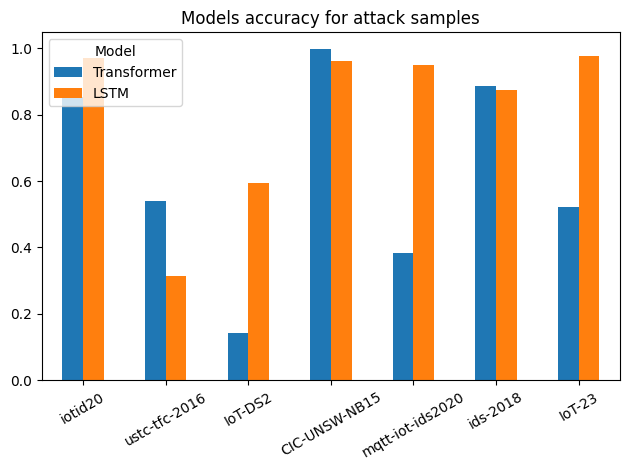

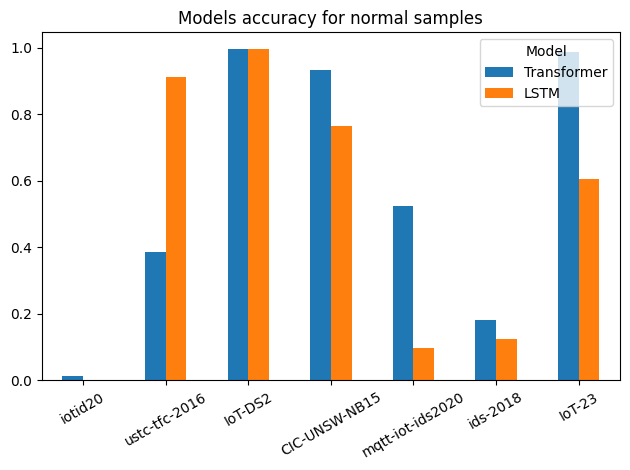

In [30]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/zero_shot/with_network_specific_features/30_epochs_early_stop/results_transformer_TL_zero_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/zero_shot/with_network_specific_features/5_epochs_early_stop/results_lstm_TL_zero_shot.csv")
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")


Binary metrics:

                        iotid20  ustc-tfc-2016   IoT-DS2  CIC-UNSW-NB15  mqtt-iot-ids2020  ids-2018    IoT-23
Metric    Model                                                                                              
Accuracy  Transformer  0.442512       0.348997  0.639258       0.265818          0.431983  0.510612  0.689743
          LSTM         0.480277       0.681152  0.785511       0.844173          0.495992  0.538381  0.941946
          CNN          0.580722       0.440682  0.560162       0.584159          0.458740  0.560170  0.755870
Precision Transformer  0.362090       0.319361  0.583048       0.060025          0.442255  0.519640  0.619498
          LSTM         0.129702       0.624577  0.701513       0.916072          0.666672  0.684234  0.980392
          CNN          0.427615       0.146252  0.537412       0.498442          0.464592  0.672960  0.683514
Recall    Transformer  0.318696       0.258183  0.993529       0.025953          0.514586  0.285416  0.991001
          

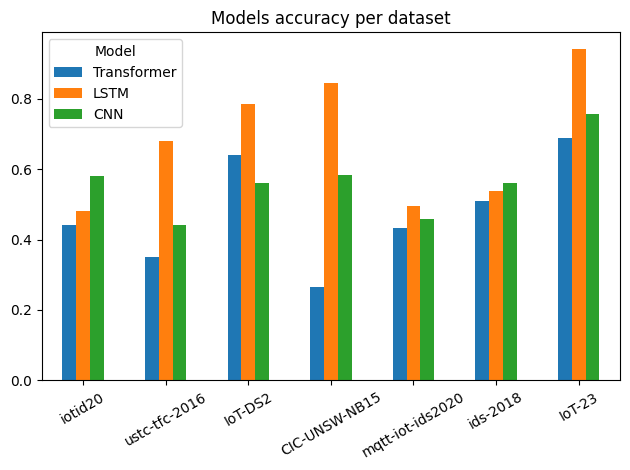

In [5]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/zero_shot/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_zero_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/zero_shot/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_zero_shot.csv")
cnn_csv = os.path.join(RESULTS_DIR, "cnn/zero_shot/with_network_specific_features/30_epochs_early_stop/results_cnn_TL_zero_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "F1 Score")

print_binary_models_metrics(transformer_csv, lstm_csv, cnn_csv)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_zero_shot.pdf")


#### Network specific features removed

Binary metrics:

                        iotid20  ustc-tfc-2016   IoT-DS2  CIC-UNSW-NB15  mqtt-iot-ids2020  ids-2018    IoT-23
Metric    Model                                                                                              
Accuracy  Transformer  0.496847       0.756053  0.796112       0.749771          0.560124  0.618811  0.504940
          LSTM         0.487179       0.534966  0.798052       0.619331          0.407492  0.513950  0.843218
          CNN          0.505494       0.718639  0.740401       0.664348          0.483941  0.459344  0.472511
Precision Transformer  0.465733       0.752618  0.715728       0.812419          0.567027  0.726762  0.902938
          LSTM         0.093153       0.535404  0.718606       0.759979          0.318341  0.558972  0.969051
          CNN          0.481029       0.731672  0.651819       0.690624          0.451505  0.440401  0.390075
Recall    Transformer  0.006111       0.759168  0.983617       0.648748          0.476609  0.379935  0.011377
          

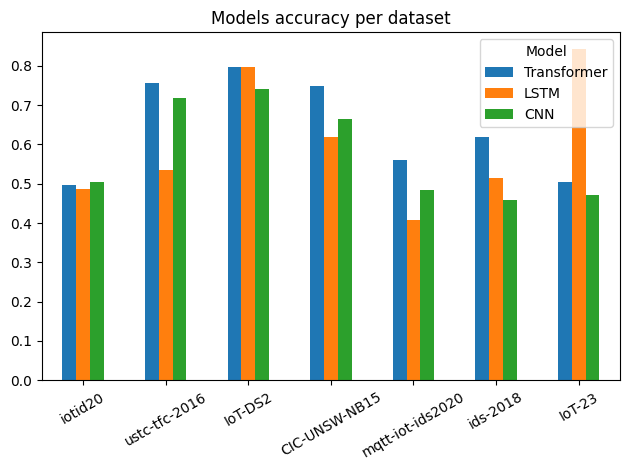

In [6]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/zero_shot/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_zero_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/zero_shot/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_zero_shot.csv")
cnn_csv = os.path.join(RESULTS_DIR, "cnn/zero_shot/separate_removed_features/30_epochs_early_stop/results_cnn_TL_removed_zero_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "F1 Score")

print_binary_models_metrics(transformer_csv, lstm_csv, cnn_csv)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_zero_shot.pdf")

### Few shot transfer learning
The following results are for 10000 samples per class infused from test set into the training set. Binary metrics only.
#### All network features included


                        iotid20  ustc-tfc-2016   IoT-DS2  CIC-UNSW-NB15  mqtt-iot-ids2020  ids-2018    IoT-23
Metric    Model                                                                                              
Accuracy  Transformer  0.668673       0.677672  0.715088       0.361103          0.637590  0.777650  0.835684
          LSTM         0.937343       0.991971  0.974902       0.971167          0.966314  0.933418  0.997219
          CNN          0.691955       0.605383  0.715131       0.904244          0.588973  0.664365  0.850345
Precision Transformer  0.673497       0.707342  0.644347       0.180972          0.587465  0.859461  0.758334
          LSTM         0.937236       0.991361  0.954695       0.988179          0.939566  0.939234  0.997967
          CNN          0.604490       0.405114  0.663622       0.898754          0.557035  0.771681  0.785968
Recall    Transformer  0.647214       0.624235  0.995254       0.189429          0.895754  0.668764  0.991397
          

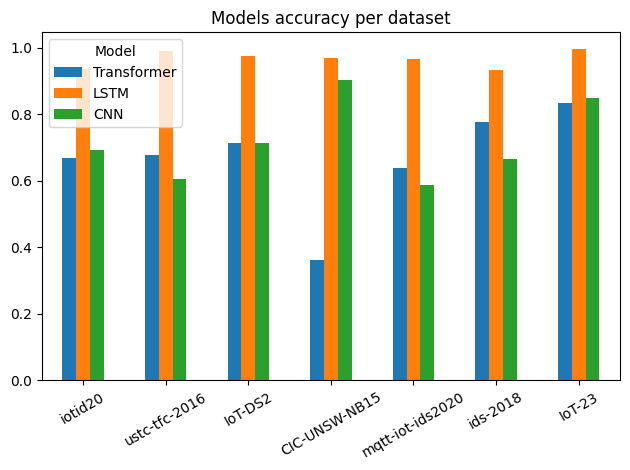

In [7]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10000_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10000_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
cnn_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/10000_samples/with_network_specific_features/30_epochs_early_stop/results_cnn_TL_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "F1 Score")

print_binary_models_metrics(transformer_csv, lstm_csv, cnn_csv)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_10000.pdf")

#### Without network-specific features
Binary metrics:

                        iotid20  ustc-tfc-2016   IoT-DS2  CIC-UNSW-NB15  mqtt-iot-ids2020  ids-2018    IoT-23
Metric    Model                                                                                              
Accuracy  Transformer  0.910047       0.973680  0.968929       0.955383          0.962776  0.912984  0.991801
          LSTM         0.924020       0.939363  0.975298       0.893635          0.961404  0.879786  0.996096
          CNN          0.629352       0.823388  0.861981       0.750574          0.697011  0.566281  0.947958
Precision Transformer  0.943807       0.981097  0.954439       0.953103          0.934676  0.915330  0.998680
          LSTM         0.944951       0.943205  0.956459       0.930415          0.935768  0.914264  0.996104
          CNN          0.625163       0.889571  0.795899       0.747609          0.792556  0.643100  0.931766
Recall    Transformer  0.872716       0.966073  0.984911       0.958992          0.995110  0.913252  0.984904
          

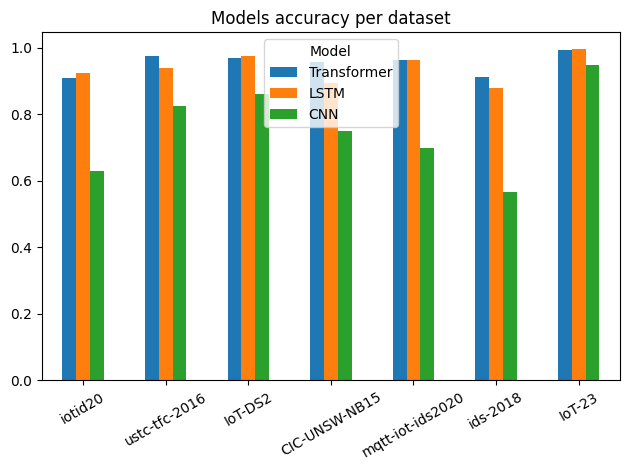

In [34]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10000_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10000_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
cnn_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/10000_samples/separate_removed_features/30_epochs_early_stop/results_cnn_TL_removed_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "F1 Score")

print_binary_models_metrics(transformer_csv, lstm_csv, cnn_csv)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_10000.pdf")


The following results are for 1000 samples per class infused from test set into the training set.
#### All network features included

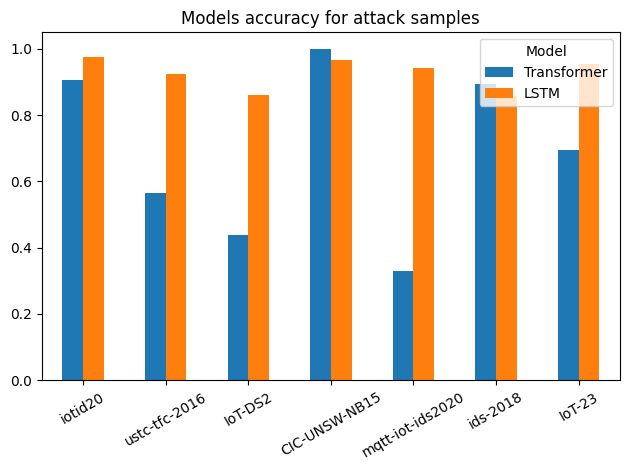

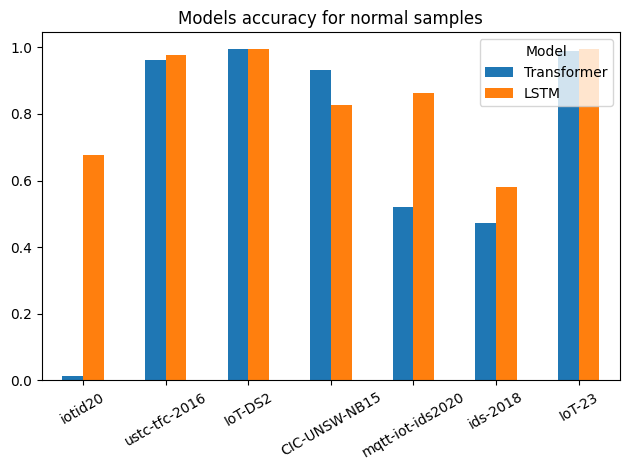

In [35]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/results_transformer_TL_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/with_network_specific_features/5_epochs_early_stop/results_lstm_TL_few_shot.csv")
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")

Binary metrics:

                        iotid20  ustc-tfc-2016   IoT-DS2  CIC-UNSW-NB15  mqtt-iot-ids2020  ids-2018    IoT-23
Metric    Model                                                                                              
Accuracy  Transformer  0.462054       0.506843  0.632233       0.372266          0.504972  0.672895  0.732489
          LSTM         0.885160       0.957463  0.927578       0.894476          0.911931  0.749062  0.994973
          CNN          0.512573       0.493022  0.565208       0.638768          0.430503  0.561142  0.844340
Precision Transformer  0.375981       0.502745  0.582560       0.288105          0.505164  0.696058  0.655793
          LSTM         0.970754       0.951345  0.878425       0.912394          0.937130  0.851218  0.997363
          CNN          0.371045       0.196637  0.546502       0.603216          0.447478  0.683532  0.775805
Recall    Transformer  0.326787       0.519303  0.969768       0.132004          0.553069  0.635635  0.990618
          

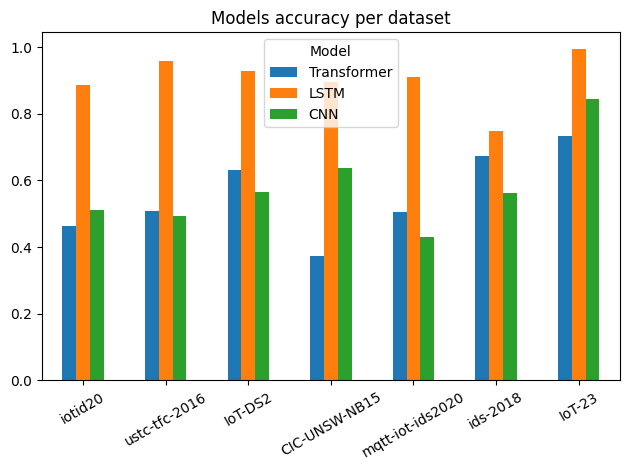

In [8]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
cnn_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/results_cnn_TL_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "F1 Score")

print_binary_models_metrics(transformer_csv, lstm_csv, cnn_csv)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_1000.pdf")

#### Without network-specific features

Binary metrics:

                        iotid20  ustc-tfc-2016   IoT-DS2  CIC-UNSW-NB15  mqtt-iot-ids2020  ids-2018    IoT-23
Metric    Model                                                                                              
Accuracy  Transformer  0.803866       0.913106  0.920656       0.864119          0.942855  0.819555  0.991089
          LSTM         0.768467       0.869748  0.902392       0.804896          0.847047  0.740825  0.993615
          CNN          0.527234       0.762666  0.814235       0.696880          0.494983  0.518696  0.571109
Precision Transformer  0.843459       0.913659  0.928496       0.864524          0.944251  0.820498  0.991204
          LSTM         0.894334       0.910248  0.844232       0.855088          0.876461  0.833092  0.996136
          CNN          0.484242       0.811843  0.742160       0.707433          0.517661  0.546229  0.538087
Recall    Transformer  0.803866       0.913106  0.920656       0.864119          0.942855  0.819555  0.991089
          

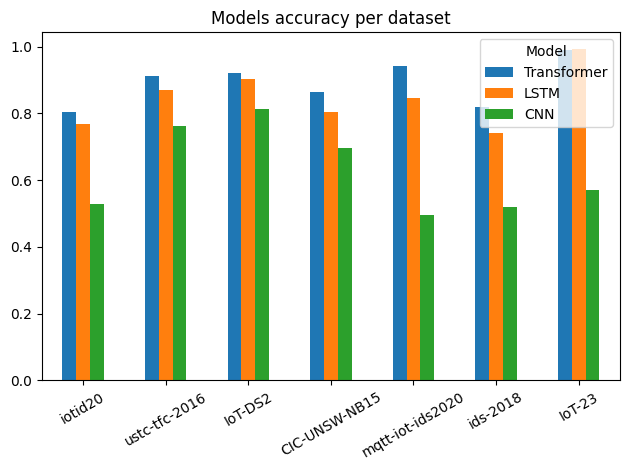

In [9]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
cnn_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/1000_samples/separate_removed_features/30_epochs_early_stop/results_cnn_TL_removed_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv, "F1 Score")

print_binary_models_metrics(transformer_csv, lstm_csv, cnn_csv)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_1000.pdf")

The following results are for 100 samples per class infused from test set into the training set.
#### With network specific features:

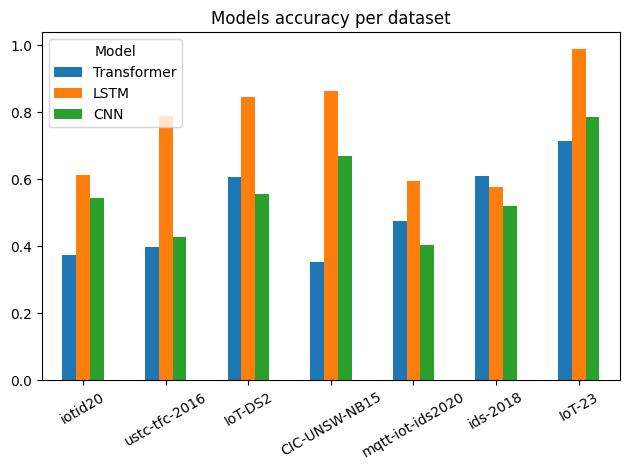

In [38]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/100_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/100_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
cnn_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/100_samples/with_network_specific_features/30_epochs_early_stop/results_cnn_TL_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_100.pdf")

#### Without network specific features:


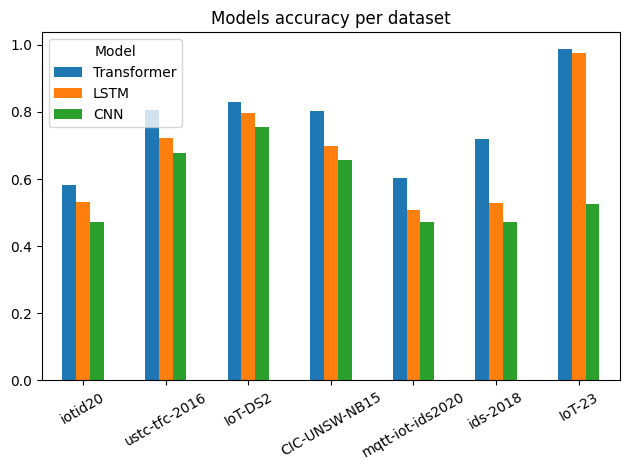

In [39]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/100_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/100_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
cnn_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/100_samples/separate_removed_features/30_epochs_early_stop/results_cnn_TL_removed_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_100.pdf")

The following results are for 10 samples per class infused from test set into training set
#### With network specific features

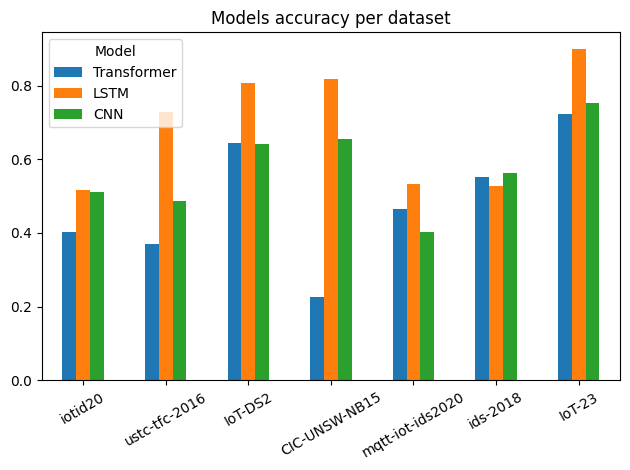

In [40]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
cnn_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/10_samples/with_network_specific_features/30_epochs_early_stop/results_cnn_TL_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_10.pdf")

#### Without network specific features

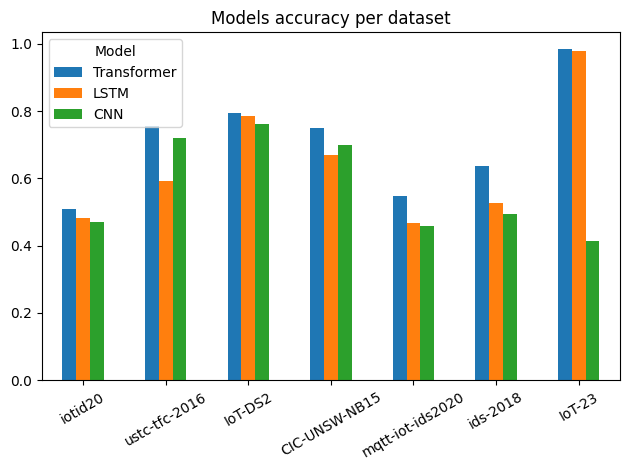

In [41]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
cnn_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/10_samples/separate_removed_features/30_epochs_early_stop/results_cnn_TL_removed_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, cnn_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_10.pdf")

## Overall average performance per model
How infusion and network specific features affects overall model performance

### With network specific features

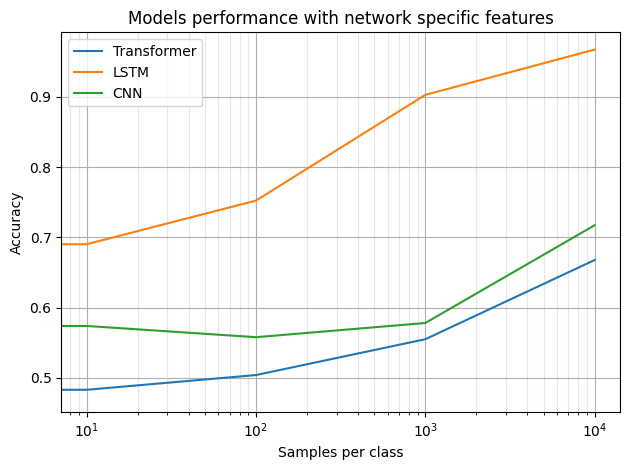

In [42]:
transformer_0_csv = os.path.join(RESULTS_DIR, "transformer/zero_shot/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_zero_shot.csv")
transformer_10_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
transformer_100_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/100_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
transformer_1000_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
transformer_10000_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10000_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")

lstm_0_csv = os.path.join(RESULTS_DIR, "lstm/zero_shot/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_zero_shot.csv")
lstm_10_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
lstm_100_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/100_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
lstm_1000_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
lstm_10000_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10000_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")

cnn_0_csv = os.path.join(RESULTS_DIR, "cnn/zero_shot/with_network_specific_features/30_epochs_early_stop/results_cnn_TL_zero_shot.csv")
cnn_10_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/10_samples/with_network_specific_features/30_epochs_early_stop/results_cnn_TL_few_shot.csv")
cnn_100_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/100_samples/with_network_specific_features/30_epochs_early_stop/results_cnn_TL_few_shot.csv")
cnn_1000_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/results_cnn_TL_few_shot.csv")
cnn_10000_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/10000_samples/with_network_specific_features/30_epochs_early_stop/results_cnn_TL_few_shot.csv")

transformer_csvs = [transformer_0_csv, transformer_10_csv, transformer_100_csv, transformer_1000_csv, transformer_10000_csv]
lstm_csvs = [lstm_0_csv, lstm_10_csv, lstm_100_csv, lstm_1000_csv, lstm_10000_csv]
cnn_csvs = [cnn_0_csv, cnn_10_csv, cnn_100_csv, cnn_1000_csv, cnn_10000_csv]
transformer_avg_accuracies = []
lstm_avg_accuracies = []
cnn_avg_accuracies = []

for i in range(len(transformer_csvs)):
    accuracy_per_model = get_binary_models_performance(transformer_csvs[i], lstm_csvs[i], cnn_csvs[i]).T
    transformer_avg_accuracies.append(accuracy_per_model["Transformer"].mean())
    lstm_avg_accuracies.append(accuracy_per_model["LSTM"].mean())
    cnn_avg_accuracies.append(accuracy_per_model["CNN"].mean())

plt.plot([0, 10, 100, 1000, 10000], transformer_avg_accuracies, label="Transformer")
plt.plot([0, 10, 100, 1000, 10000], lstm_avg_accuracies, label="LSTM")
plt.plot([0, 10, 100, 1000, 10000], cnn_avg_accuracies, label="CNN")
plt.semilogx()
plt.legend()
plt.grid()
plt.grid(which='minor', color="0.9")
plt.title("Models performance with network specific features")
plt.xlabel("Samples per class")
plt.ylabel("Accuracy")
plt.tight_layout(h_pad=3)
plt.savefig("model_performance_overall.pdf")


### Without network specific features


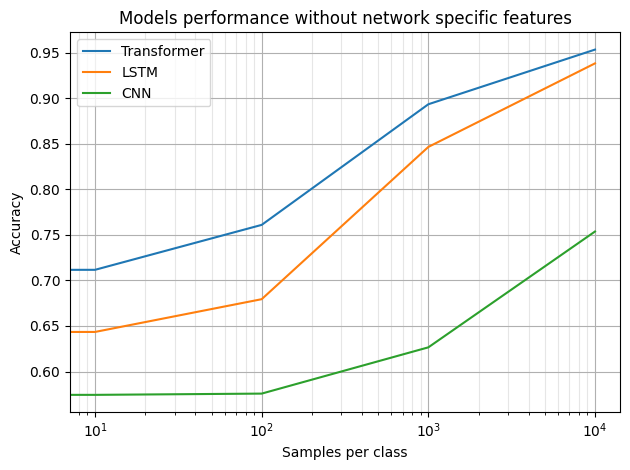

In [43]:
transformer_0_csv = os.path.join(RESULTS_DIR, "transformer/zero_shot/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_zero_shot.csv")
transformer_10_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
transformer_100_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/100_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
transformer_1000_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
transformer_10000_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10000_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")

lstm_0_csv = os.path.join(RESULTS_DIR, "lstm/zero_shot/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_zero_shot.csv")
lstm_10_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
lstm_100_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/100_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
lstm_1000_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
lstm_10000_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10000_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")

cnn_0_csv = os.path.join(RESULTS_DIR, "cnn/zero_shot/separate_removed_features/30_epochs_early_stop/results_cnn_TL_removed_zero_shot.csv")
cnn_10_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/10_samples/separate_removed_features/30_epochs_early_stop/results_cnn_TL_removed_few_shot.csv")
cnn_100_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/100_samples/separate_removed_features/30_epochs_early_stop/results_cnn_TL_removed_few_shot.csv")
cnn_1000_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/1000_samples/separate_removed_features/30_epochs_early_stop/results_cnn_TL_removed_few_shot.csv")
cnn_10000_csv = os.path.join(RESULTS_DIR, "cnn/few_shot/10000_samples/separate_removed_features/30_epochs_early_stop/results_cnn_TL_removed_few_shot.csv")

transformer_csvs = [transformer_0_csv, transformer_10_csv, transformer_100_csv, transformer_1000_csv, transformer_10000_csv]
lstm_csvs = [lstm_0_csv, lstm_10_csv, lstm_100_csv, lstm_1000_csv, lstm_10000_csv]
cnn_csvs = [cnn_0_csv, cnn_10_csv, cnn_100_csv, cnn_1000_csv, cnn_10000_csv]
transformer_avg_accuracies = []
lstm_avg_accuracies = []
cnn_avg_accuracies = []

for i in range(len(transformer_csvs)):
    accuracy_per_model = get_binary_models_performance(transformer_csvs[i], lstm_csvs[i], cnn_csvs[i]).T
    transformer_avg_accuracies.append(accuracy_per_model["Transformer"].mean())
    lstm_avg_accuracies.append(accuracy_per_model["LSTM"].mean())
    cnn_avg_accuracies.append(accuracy_per_model["CNN"].mean())

plt.plot([0, 10, 100, 1000, 10000], transformer_avg_accuracies, label="Transformer")
plt.plot([0, 10, 100, 1000, 10000], lstm_avg_accuracies, label="LSTM")
plt.plot([0, 10, 100, 1000, 10000], cnn_avg_accuracies, label="CNN")
plt.semilogx()
plt.legend()
plt.grid()
plt.grid(which='minor', color="0.9")
plt.title("Models performance without network specific features")
plt.xlabel("Samples per class")
plt.ylabel("Accuracy")
plt.tight_layout(h_pad=3)
plt.savefig("model_performance_overall_removed.pdf")